In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Use Arial for all plots where available. If Arial isn't installed, Matplotlib
# will fall back to the next available sans-serif font.
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
    # Configure mathtext to use Arial where possible (custom mapping)
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold'
})


## Metabolics - starting with anaerobic included (trimmed at bottom)

In [2]:
import os

#### % MetabolicsData.xlsx 
## use the 'Metabolics' sheet and then the % change values. 

# Check if pickle file exists, if so load it; otherwise read from clipboard and save
pickle_path = os.path.join('data', 'metabolics_data.pkl')

if os.path.exists(pickle_path):
    df = pd.read_pickle(pickle_path)
    print("Loaded data from pickle file")
else:
    df = pd.read_clipboard()
    print("Loaded data from clipboard")
    os.makedirs('data', exist_ok=True)
    df.to_pickle(pickle_path)
    print(f"Saved data to pickle: {pickle_path}")

print(df)

# old (has anaerobic)


# The easiest way is to copy the data from Excel and paste it directly into a Jupyter Notebook cell as a pandas DataFrame. You can do this by:

# 1. Copy the data from Excel.
# 2. In a new Jupyter cell, run:
#     ```python
#     df = pd.read_clipboard()
#     df
#     ```
# This will automatically read the copied table into a DataFrame called `df`.

Loaded data from pickle file
    Subject  Long-compliant  Short-stiff  Medium-original  Long-stiff  \
0         1       -2.876106   -12.094395       -14.306785   -7.448378   
1         3        3.808864    -5.678670        -4.362881  -12.811634   
2         4       -1.889169    -7.367758        -4.785894   -4.534005   
3         6        0.189633    -1.327434        -2.844501    1.201011   
4         7       -3.957947    -6.060606        -6.679035   -5.009276   
5         8       -4.116866    -8.565737       -10.823373    4.316069   
6         9       -5.058905    -2.841303        -4.712405    0.138600   
7        10       -0.407609     4.959239       -11.005435   -1.902174   
8        11        5.615697     4.533153         8.795670   10.148850   
9        12      -11.160151    -5.548550        -5.233291   -1.324086   
10       13       -2.195390    -4.555434        -6.256861   -4.116356   

    Best-performing  
0        -14.306785  
1        -12.811634  
2         -7.367758  
3     

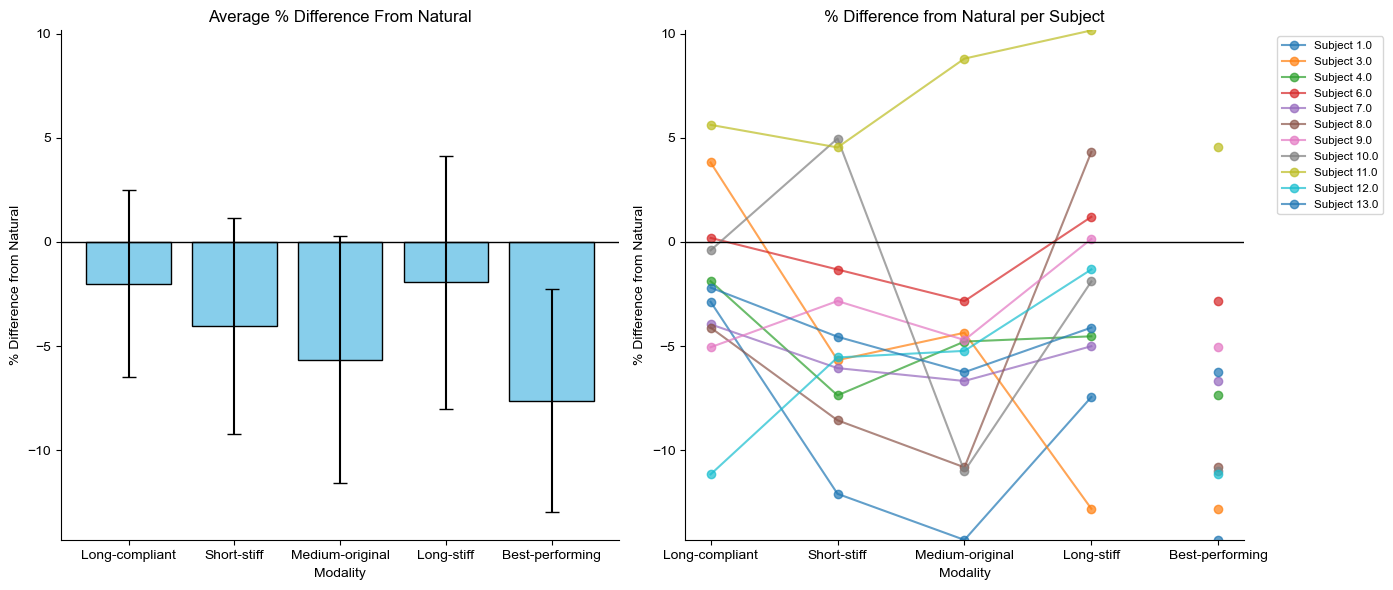

In [4]:
# old (has anaerobic)


# 1) Bar plot with averages and error bars (std)
modalities = ['Long-compliant', 'Short-stiff', 'Medium-original', 'Long-stiff', 'Best-performing']
means = df[modalities].mean()
stds = df[modalities].std()

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot
axs[0].bar(modalities, means, yerr=stds, capsize=5, color='skyblue', edgecolor='black')
axs[0].set_title('Average % Difference From Natural')
axs[0].set_ylabel('% Difference from Natural')
axs[0].set_xlabel('Modality')

# 2) Scatter plot with lines for each subject, connecting all but "Best"
for idx, row in df.iterrows():
    # Plot lines connecting Placebo, Bad, Original, Optimal
    axs[1].plot(modalities[:-1], row[modalities[:-1]], marker='o', alpha=0.7, label=f'Subject {row["Subject"]}')
    # Plot "Best" as a separate point (not connected)
    axs[1].plot(modalities[-1], row[modalities[-1]], marker='o', color=axs[1].lines[-1].get_color(), alpha=0.7)
axs[0].axhline(0, color='black', linewidth=1)
axs[1].axhline(0, color='black', linewidth=1)
axs[1].set_title('% Difference from Natural per Subject')
axs[1].set_ylabel('% Difference from Natural')
axs[1].set_xlabel('Modality')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
# Ensure both axes have the same y-axis limits
ymin = min(df[modalities].min().min(), means.min() - stds.max())
ymax = max(df[modalities].max().max(), means.max() + stds.max())
axs[0].set_ylim(ymin, ymax)
axs[1].set_ylim(ymin, ymax)

# Remove top and right borders for both subplots
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
fig.savefig(os.path.join(os.getcwd(), '../PredFigures/scores_by_modality_dualPanel.png'), dpi=300, bbox_inches='tight')


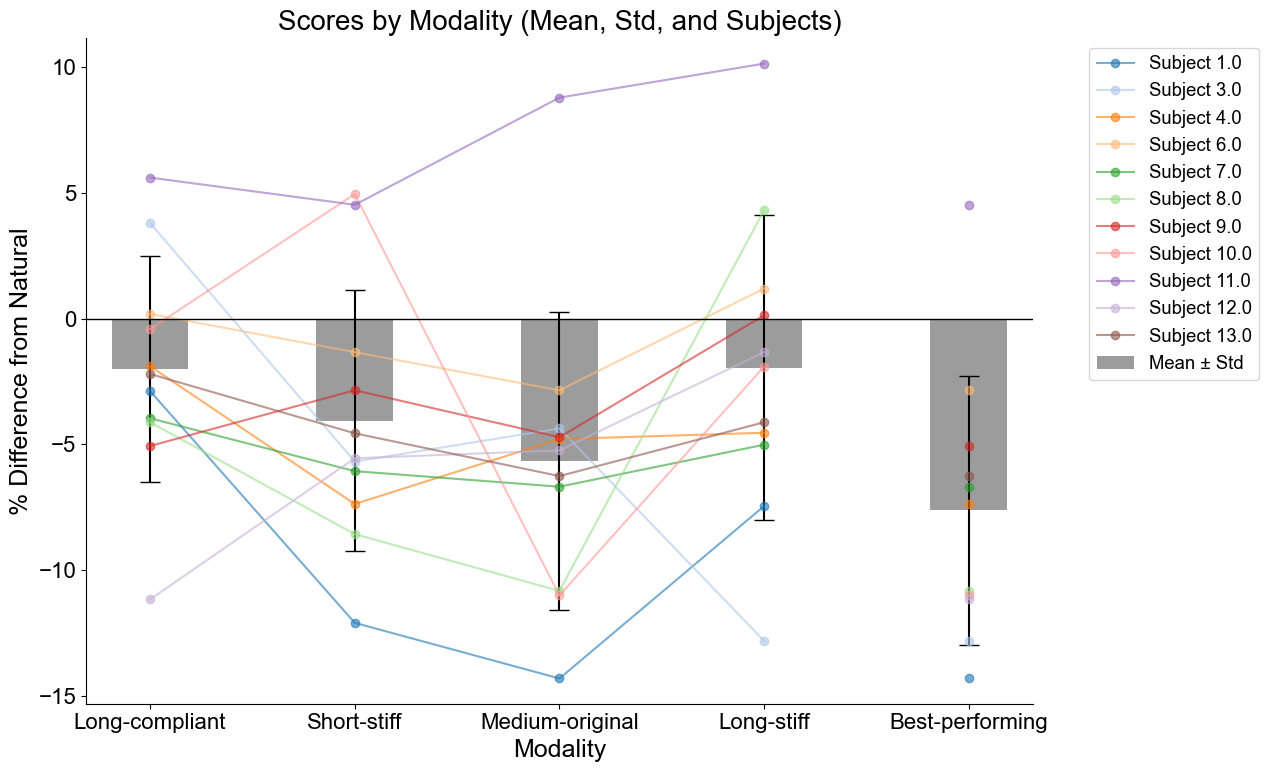

In [4]:
# old (has anaerobic)
plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16
})

fig, ax = plt.subplots(figsize=(13, 8))  # Slightly larger for more space

# Increase spacing between bars/lines
x_pos = np.arange(len(modalities)) * 3.2  # Even more spacing

# Bar plot: means and error bars at spaced positions
bar_width = 1.2
ax.bar(x_pos, means, yerr=stds, capsize=7, width=bar_width, color="#8B8B8B", alpha=0.85, linewidth=2, label='Mean ± Std')

# Define colors for each subject using a colormap to avoid NameError
cmap = plt.get_cmap('tab20')
colors = [cmap(i % cmap.N) for i in range(len(df))]

# Overlay subject lines and points at correct x positions, each with a unique color
for idx, (i, row) in enumerate(df.iterrows()):
    subject_vals = row[modalities].values
    ax.plot(x_pos[:-1], subject_vals[:-1], marker='o', alpha=0.6, color=colors[idx], label=f'Subject {row["Subject"]}')
    ax.plot(x_pos[-1], subject_vals[-1], marker='o', color=colors[idx], alpha=0.6)

ax.set_xticks(x_pos)
ax.set_xticklabels(modalities)
ax.set_title('Scores by Modality (Mean, Std, and Subjects)')
ax.set_ylabel('% Difference from Natural')
ax.set_xlabel('Modality')
ax.axhline(0, color='black', linewidth=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(ymin - 1, ymax + 1)  # More padding above/below
ax.set_xlim(x_pos[0] - 1, x_pos[-1] + 1)  # More padding left/right

# Legend for mean/std and subjects (avoid duplicate labels)
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()
fig.savefig(os.path.join(os.getcwd(), '../PredFigures/scores_by_modality.png'), dpi=500, bbox_inches='tight')


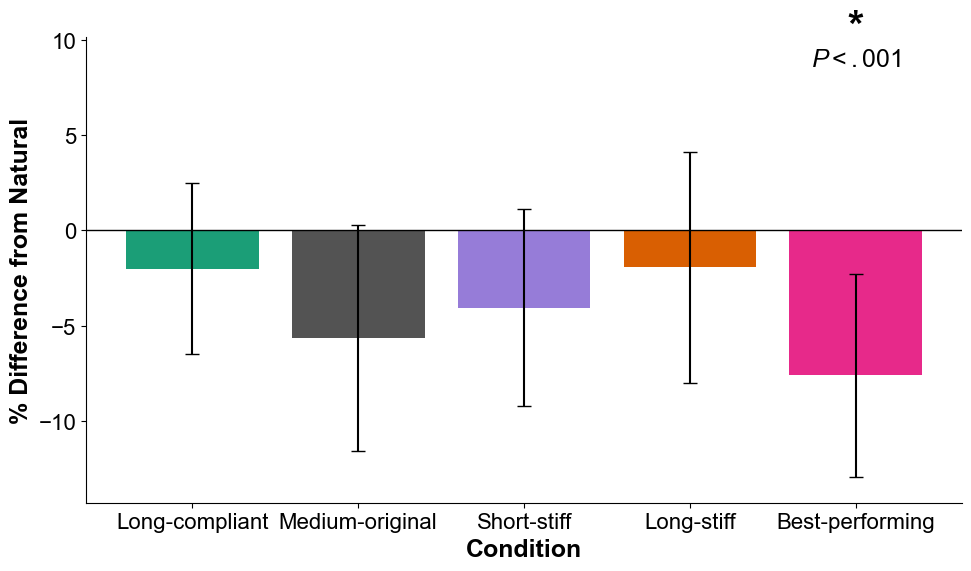

In [5]:
# old (has anaerobic)
# okay one simple bar plot that can go in the paper (with all the data)
# 1) Bar plot with averages and error bars (std)

# create a color map for the conditions
plot_colors = {
    'Short-stiff': "#967cd8",
    'Medium-original': "#535353",
    'Long-stiff': '#d95f02',
    'Long-compliant': '#1b9e77',
    'Best-performing': '#e7298a'
}

modalities = ['Long-compliant', 'Medium-original', 'Short-stiff', 'Long-stiff', 'Best-performing']
means = df[modalities].mean()
stds = df[modalities].std()
fig, ax = plt.subplots(figsize=(10, 6))

# Bar plot
ax.bar(modalities, means, yerr=stds, capsize=5, color=[plot_colors[m] for m in modalities], edgecolor='None')



ax.set_ylabel('% Difference from Natural', fontsize=18, fontweight='bold')
ax.set_xlabel('Condition', fontsize=18, fontweight='bold')
ax.axhline(0, color='black', linewidth=1)

# add significance marker above "Best-performing"
# expand top margin so the star/P-value can sit higher without overlapping the bar
ymin_tmp, ymax_tmp = ax.get_ylim()
yrange_tmp = ymax_tmp - ymin_tmp if ymax_tmp > ymin_tmp else 1.0
ax.set_ylim(ymin_tmp, ymax_tmp + 0.25 * yrange_tmp)
idx = modalities.index('Best-performing')
x = idx  # categorical bars are at integer x positions 0..N-1
ymin_curr, ymax_curr = ax.get_ylim()
yrange = ymax_curr - ymin_curr if ymax_curr > ymin_curr else 1.0
star_y = ymax_curr - 0.05
p_y = star_y - 0.04
ax.text(x, star_y, '*', ha='center', va='bottom', fontsize=30, fontweight='bold', zorder=10)
ax.text(x, p_y, r"$\mathit{P}<.001$", ha='center', va='top', fontsize=18, zorder=10)

# Ensure y-limits as before
ymin = min(df[modalities].min().min(), means.min() - stds.max())
ymax = max(df[modalities].max().max(), means.max() + stds.max())
ax.set_ylim(ymin, ymax)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
fig.savefig(os.path.join(os.getcwd(), '../PredFigures/scores_by_modality_singlePanel.png'), dpi=500, bbox_inches='tight')


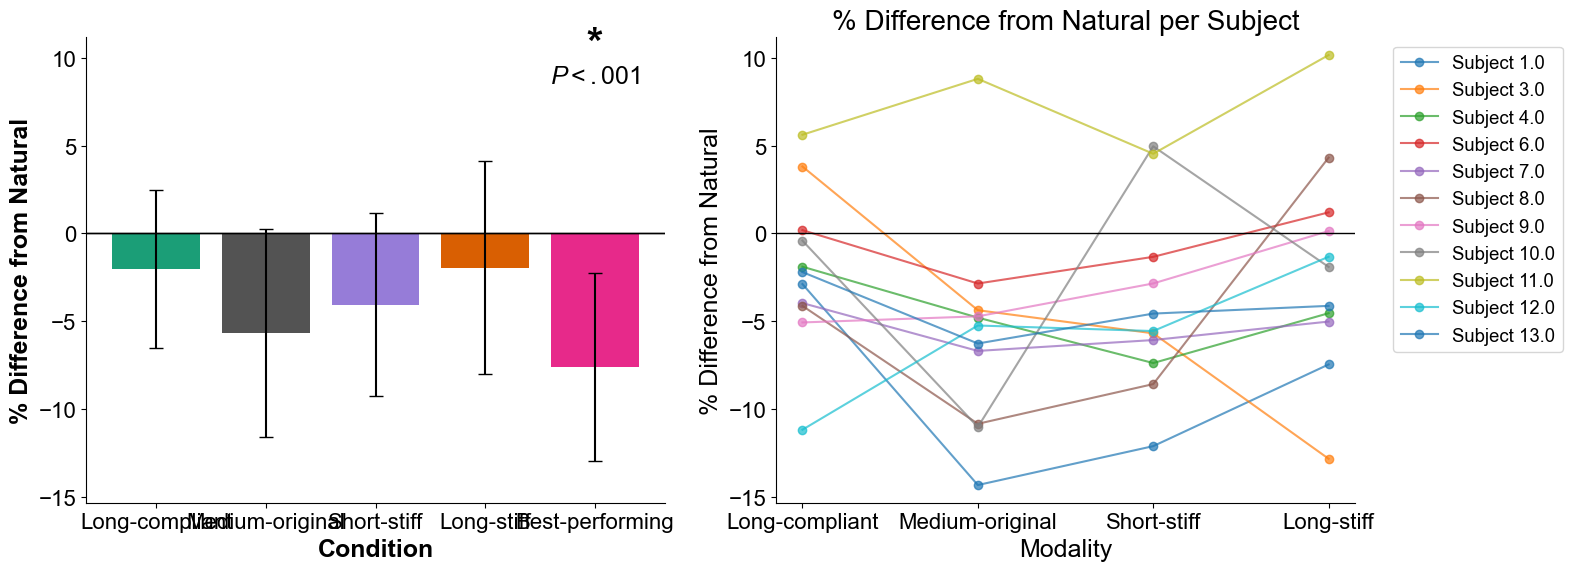

In [8]:
# old (has anaerobic)


# 1) Bar plot with averages and error bars (std)
modalities = ['Long-compliant', 'Short-stiff', 'Medium-original', 'Long-stiff', 'Best-performing']
means = df[modalities].mean()
stds = df[modalities].std()



# create a color map for the conditions
plot_colors = {
    'Short-stiff': "#967cd8",
    'Medium-original': "#535353",
    'Long-stiff': '#d95f02',
    'Long-compliant': '#1b9e77',
    'Best-performing': '#e7298a'
}

modalities = ['Long-compliant', 'Medium-original', 'Short-stiff', 'Long-stiff', 'Best-performing']
means = df[modalities].mean()
stds = df[modalities].std()
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
axs[0].bar(modalities, means, yerr=stds, capsize=5, color=[plot_colors[m] for m in modalities], edgecolor='None')


axs[0].set_ylabel('% Difference from Natural', fontsize=18, fontweight='bold')
axs[0].set_xlabel('Condition', fontsize=18, fontweight='bold')
axs[0].axhline(0, color='black', linewidth=1)

# add significance marker above "Best-performing"
# expand top margin so the star/P-value can sit higher without overlapping the bar
ymin_tmp, ymax_tmp = axs[0].get_ylim()
yrange_tmp = ymax_tmp - ymin_tmp if ymax_tmp > ymin_tmp else 1.0
axs[0].set_ylim(ymin_tmp, ymax_tmp + 0.25 * yrange_tmp)
idx = modalities.index('Best-performing')
x = idx  # categorical bars are at integer x positions 0..N-1
ymin_curr, ymax_curr = axs[0].get_ylim()
yrange = ymax_curr - ymin_curr if ymax_curr > ymin_curr else 1.0
star_y = ymax_curr - 0.05
p_y = star_y - 0.04
axs[0].text(x, star_y, '*', ha='center', va='bottom', fontsize=30, fontweight='bold', zorder=10)
axs[0].text(x, p_y, r"$\mathit{P}<.001$", ha='center', va='top', fontsize=18, zorder=10)


# 2) Scatter plot with lines for each subject, connecting all but "Best"
for idx, row in df.iterrows():
    # Plot lines connecting Placebo, Bad, Original, Optimal
    axs[1].plot(modalities[:-1], row[modalities[:-1]], marker='o', alpha=0.7, label=f'Subject {row["Subject"]}')
    # Plot "Best" as a separate point (not connected)
    # axs[1].plot(modalities[-1], row[modalities[-1]], marker='o', color=axs[1].lines[-1].get_color(), alpha=0.7)
axs[0].axhline(0, color='black', linewidth=1)
axs[1].axhline(0, color='black', linewidth=1)
axs[1].set_title('% Difference from Natural per Subject')
axs[1].set_ylabel('% Difference from Natural')
axs[1].set_xlabel('Modality')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')


# Ensure both axes have the same y-axis limits
ymin = min(df[modalities].min().min(), means.min() - stds.max())
ymax = max(df[modalities].max().max(), means.max() + stds.max())
axs[0].set_ylim(ymin-1, ymax+1)
axs[1].set_ylim(ymin-1, ymax+1)

# Remove top and right borders for both subplots
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.show()
fig.savefig(os.path.join(os.getcwd(), '../PredFigures/scores_by_modality_dualPanel.png'), dpi=300, bbox_inches='tight')


/var/folders/_d/s3xm67814b79vmjwbcsk9hn00000gn/T/ipykernel_46318/3606571564.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(modalities_staggered)
/var/folders/_d/s3xm67814b79vmjwbcsk9hn00000gn/T/ipykernel_46318/3606571564.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(modalities_staggered[0:-1])


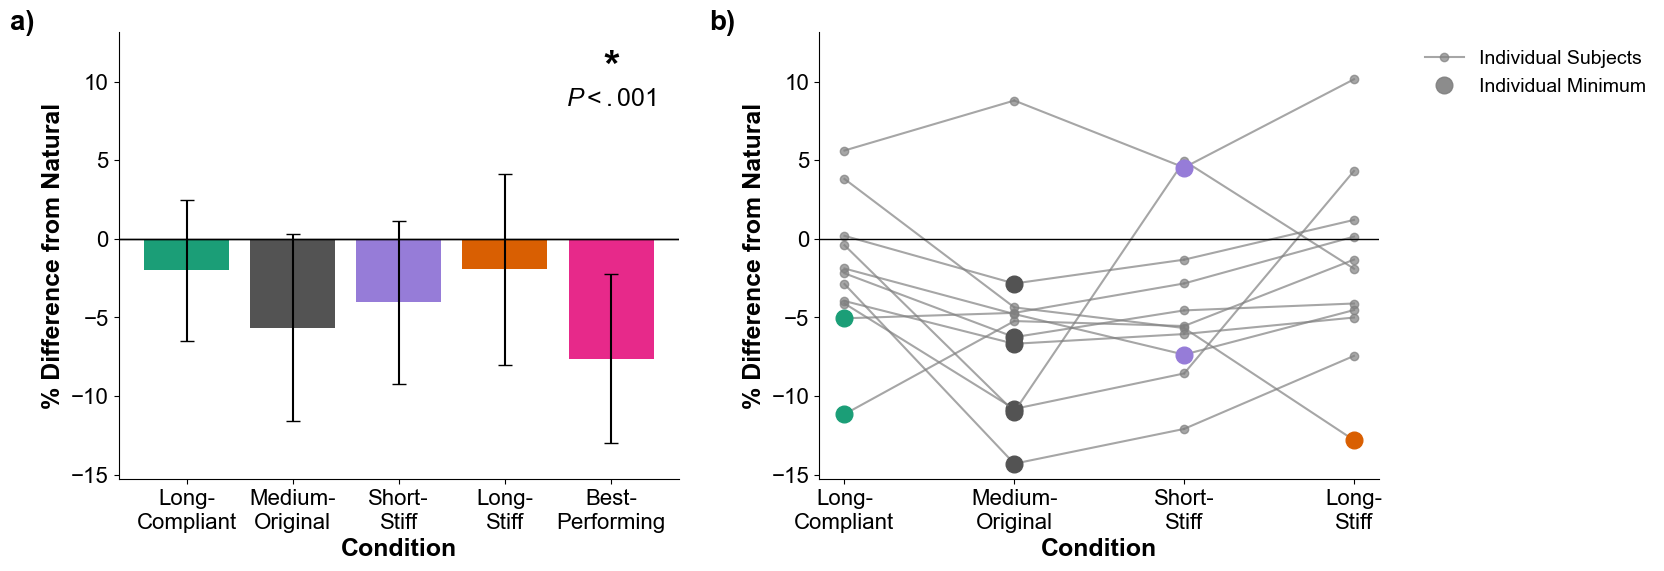

In [9]:
from matplotlib.lines import Line2D
# old (has anaerobic)

# 1) Bar plot with averages and error bars (std)
modalities = ['Long-compliant', 'Short-stiff', 'Medium-original', 'Long-stiff', 'Best-performing']
means = df[modalities].mean()
stds = df[modalities].std()

# create a color map for the conditions
plot_colors = {
    'Short-stiff': "#967cd8",
    'Medium-original': "#535353",
    'Long-stiff': '#d95f02',
    'Long-compliant': '#1b9e77',
    'Best-performing': '#e7298a'
}

modalities = ['Long-compliant', 'Medium-original', 'Short-stiff', 'Long-stiff', 'Best-performing']
modalities_staggered = ['Long-\nCompliant', 'Medium-\nOriginal', 'Short-\nStiff', 'Long-\nStiff', 'Best-\nPerforming']
means = df[modalities].mean()
stds = df[modalities].std()
fig, axs = plt.subplots(1, 2, figsize=(17, 6))

# Bar plot
axs[0].bar(modalities, means, yerr=stds, capsize=5, color=[plot_colors[m] for m in modalities], edgecolor='None')
axs[0].set_ylabel('% Difference from Natural', fontsize=18, fontweight='bold')
axs[0].set_xlabel('Condition', fontsize=18, fontweight='bold')
axs[0].axhline(0, color='black', linewidth=1)
# add significance marker above "Best-performing"
# expand top margin so the star/P-value can sit higher without overlapping the bar
ymin_tmp, ymax_tmp = axs[0].get_ylim()
yrange_tmp = ymax_tmp - ymin_tmp if ymax_tmp > ymin_tmp else 1.0
axs[0].set_ylim(ymin_tmp, ymax_tmp + 0.25 * yrange_tmp)
idx = modalities.index('Best-performing')
x = idx  # categorical bars are at integer x positions 0..N-1
ymin_curr, ymax_curr = axs[0].get_ylim()
yrange = ymax_curr - ymin_curr if ymax_curr > ymin_curr else 1.0
star_y = ymax_curr - 0.05
p_y = star_y - 0.04
axs[0].text(x, star_y, '*', ha='center', va='bottom', fontsize=30, fontweight='bold', zorder=10)
axs[0].text(x, p_y, r"$\mathit{P}<.001$", ha='center', va='top', fontsize=18, zorder=10)
axs[0].set_xticklabels(modalities_staggered)

# 2) Scatter plot with lines for each subject, connecting all but "Best"
# Plot each subject's curve with color based on their minimum point
for idx, row in df.iterrows():
    # Find the minimum value among all modalities (excluding Best-individual)
    min_idx = row[modalities[:-1]].idxmin()
    
    # Get the color based on the minimum condition
    line_color = plot_colors.get(min_idx, 'grey')
    
    # Find the position of the minimum in the modalities list
    min_pos = modalities.index(min_idx)
    
    # Plot lines connecting all modalities except "Best" in the subject's color
    for i in range(len(modalities[:-1]) - 1):
        axs[1].plot(modalities[i:i+2], row[modalities[i:i+2]], 
                   color='grey', alpha=0.7, linewidth=1.5)
    
    # Plot all markers with standard size
    for i, mod in enumerate(modalities[:-1]):
        if i == min_pos:
            # Make the minimum point marker larger
            axs[1].plot(mod, row[mod], marker='o', markersize=12, 
                       color=line_color, alpha=1)
        else:
            axs[1].plot(mod, row[mod], marker='o', markersize=6, 
                       color='grey', alpha=0.7)

axs[0].axhline(0, color='black', linewidth=1)
axs[1].axhline(0, color='black', linewidth=1)
# axs[1].set_title('% Difference from Natural per Subject')
axs[1].set_ylabel('% Difference from Natural', fontsize=18, fontweight='bold')
axs[1].set_xlabel('Condition', fontsize=18, fontweight='bold')
axs[1].set_xticklabels(modalities_staggered[0:-1])

legend_elements = [
    Line2D([0], [0], color='grey', marker='o', markersize=6, linewidth=1.5, alpha=0.7, label='Individual Subjects'),
    Line2D([0], [0], color='none', marker='o', markerfacecolor='grey', markeredgecolor='grey', markersize=12, linewidth=0, alpha=0.9, label='Individual Minimum')
]
axs[1].legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, frameon=False)
# # Get current y-limits to position legend in upper white space
# ymin_curr, ymax_curr = axs[1].get_ylim()
# # Position legend at approximately 70% of the y-range (middle of upper white space)
# legend_y = ymin_curr + 0.70 * (ymax_curr - ymin_curr)
# axs[1].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.3, 0.98), fontsize=14, frameon=False)

# Add panel letters to subplots
axs[0].text(-0.15, 1.05, 'a)', transform=axs[0].transAxes, 
            fontsize=20, fontweight='bold', va='top', ha='right')
axs[1].text(-0.15, 1.05, 'b)', transform=axs[1].transAxes, 
            fontsize=20, fontweight='bold', va='top', ha='right')

# Ensure both axes have the same y-axis limits
ymin = min(df[modalities].min().min(), means.min() - stds.max())
ymax = max(df[modalities].max().max(), means.max() + stds.max())
axs[0].set_ylim(ymin-1, ymax+3)
axs[1].set_ylim(ymin-1, ymax+3)

# Remove top and right borders for both subplots
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.show()
fig.savefig(os.path.join(os.getcwd(), '../PredFigures/scores_by_modality_dualPanel.png'), dpi=300, bbox_inches='tight')


In [10]:
#### NET cost values for metabolics. 
df_raw = pd.read_clipboard()

ParserError: Expected 10 fields in line 41, saw 14. Error could possibly be due to quotes being ignored when a multi-char delimiter is used.

KeyError: 'Natural'

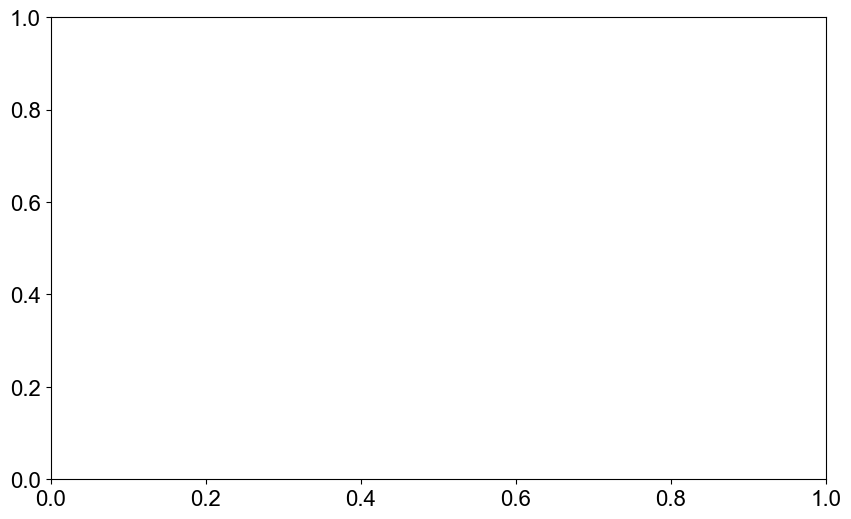

In [9]:

# Bar plot for 'Natural' and 'Best' columns
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.bar(df_raw.index - 0.2, df_raw['Natural'], width=0.4, label='Natural', color='orange', edgecolor='black')
ax2.bar(df_raw.index + 0.2, df_raw['Best'], width=0.4, label='Best', color="#C56BC5", edgecolor='black')

ax2.set_xlabel('Subject')
ax2.set_ylabel('Raw Value')
ax2.set_title('Natural vs Best Raw Values')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16
})


KeyError: 'Natural'

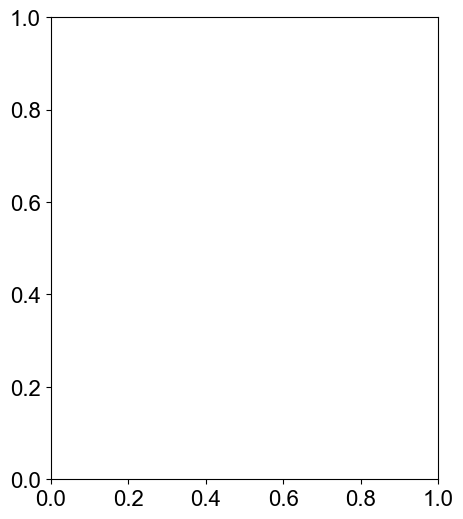

In [10]:
fig3, ax3 = plt.subplots(figsize=(5, 6))

# Set font sizes globally for the plot
plt.rcParams.update({'font.size': 16, 'axes.labelsize': 18, 'axes.titlesize': 20, 'xtick.labelsize': 16, 'ytick.labelsize': 16, 'legend.fontsize': 16})

# Compute the averages used for the bars (prevent NameError)
avg_natural = df_raw['Natural'].mean()
avg_best = df_raw['Best'].mean()

ax3.bar(['Natural', 'Best'],
    [avg_natural, avg_best],
    yerr=[df_raw['Natural'].std(), df_raw['Best'].std()],
    color=['orange', '#C56BC5'],
    edgecolor='black',
    capsize=5)
ax3.set_ylabel('Average Raw Value')
# ax3.set_title('Average Natural vs Best Raw Values')
ax3.set_ylim(12, 16)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
fig3.savefig(os.path.join(os.getcwd(), '../PredFigures/natural_vs_best_2bars.png'), dpi=300, bbox_inches='tight')


In [11]:
# import all the raw data from clipboard (should already be done from above... I think)
# df_raw = pd.read_clipboard()
df_raw.head()
print(df_raw.keys())

Index(['Eleven', 'participants', 'trained', 'with', 'each', 'of', 'the',
       'four', 'exotendon', 'designs', 'identified', 'with.1', 'simulation',
       'over', 'two', 'sessions', 'for', 'a', 'minimum', 'training', 'time',
       'of.1', '36', 'minutes', 'with.2', 'each.1', 'design.', 'After',
       'training.1', 'participants.1', 'were', 'evaluated', 'during', 'a.1',
       'third', 'session,', 'during.1', 'which', 'they', 'ran', 'on', 'an',
       'instrumented', 'treadmill', 'at', '4', 'm/s', 'for.1', '6',
       'minutes.1', 'using', 'each.2', 'exotendon.1', 'and', 'for.2',
       'natural', 'running', 'in', 'random', 'order.'],
      dtype='object')


In [1]:
# create map of condition names to more readable labels. 
conditions_map = {
    'Placebo': 'Long-Compliant',
    'Bad': 'Short-Stiff',
    'Original': 'Medium',
    'Optimal': 'Long-Stiff',
    'Natural': 'Natural',
    'Best': 'Best'
}
conditions = ['Placebo', 'Bad', 'Original', 'Optimal', 'Natural', 'Best']
print(df_raw.mean())


NameError: name 'df_raw' is not defined

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (6,) and arg 1 with shape (60,).

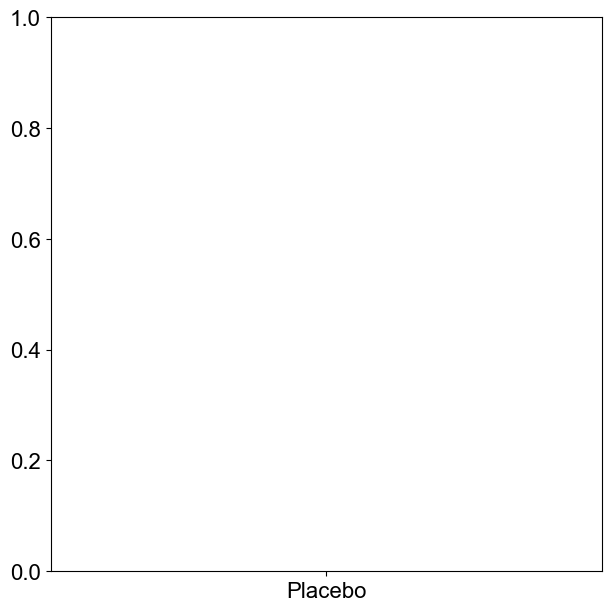

In [13]:
# Slimmer figure keeping font sizes; rotate xticklabels and use constrained_layout
fig4, ax4 = plt.subplots(figsize=(6, 6), constrained_layout=True)  # narrower width

avg_values = df_raw.mean()
std_values = df_raw.std()


ax4.bar(
    conditions,
    avg_values,
    yerr=std_values,
    color=['orange', 'purple', 'red', 'blue', 'green', 'grey'],
    edgecolor='black',
    capsize=5
)
ax4.set_ylabel('Average Raw Value')
# ax4.set_title('Average Value by Condition')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.set_ylim(12.6, 16.8)

# Rotate x labels slightly and align to avoid overlap in a narrow figure
ax4.set_xticklabels(conditions, rotation=25, ha='right')

# Add a little horizontal margin so outer bars aren't cramped
ax4.margins(x=0.06)

plt.tight_layout()
plt.show()

fig4.savefig(os.path.join(os.getcwd(), '../PredFigures/allRawValues_bar.png'), dpi=300, bbox_inches='tight')

## 5K timing, HR, cadence data


In [11]:
# all data is coming from the MetabolicsData.xlsx - this is the 5ks sheet

pickle_path = os.path.join('data', '5krun_data.pkl')

if os.path.exists(pickle_path):
    pd_5k = pd.read_pickle(pickle_path)
    print("Loaded data from pickle file")
else:
    pd_5k = pd.read_clipboard()
    print("Loaded data from clipboard")
    os.makedirs('data', exist_ok=True)
    pd_5k.to_pickle(pickle_path)
    print(f"Saved data to pickle: {pickle_path}")

print(pd_5k)

# pd_5k = pd.read_clipboard()
# print(pd_5k)




Loaded data from pickle file
   Subject  Natural     Exo  HeartNatural  HeartExo  CadenceNatural  \
0        1   1143.0  1132.0         194.0     195.0           187.0   
1        3   1089.0  1120.0         180.0     169.0           171.0   
2        4   1150.0  1153.0         182.0     177.0           166.0   
3        6   1158.0  1153.0         168.0     167.0           170.0   
4        7   1145.0  1125.0         188.0     186.0           187.0   
5        8   1134.0  1067.0         182.0     181.0           191.0   
6        9   1091.0  1075.0         193.0     187.0           182.0   
7       10   1070.0  1043.0         182.0     179.0           184.0   
8       12   1029.0  1016.0         189.0     187.0           182.0   
9       13   1189.0  1179.0         175.0     166.0           181.0   

   CadenceExo  
0       210.0  
1       195.0  
2       194.0  
3       181.0  
4       200.0  
5       209.0  
6       184.0  
7       195.0  
8       184.0  
9       208.0  


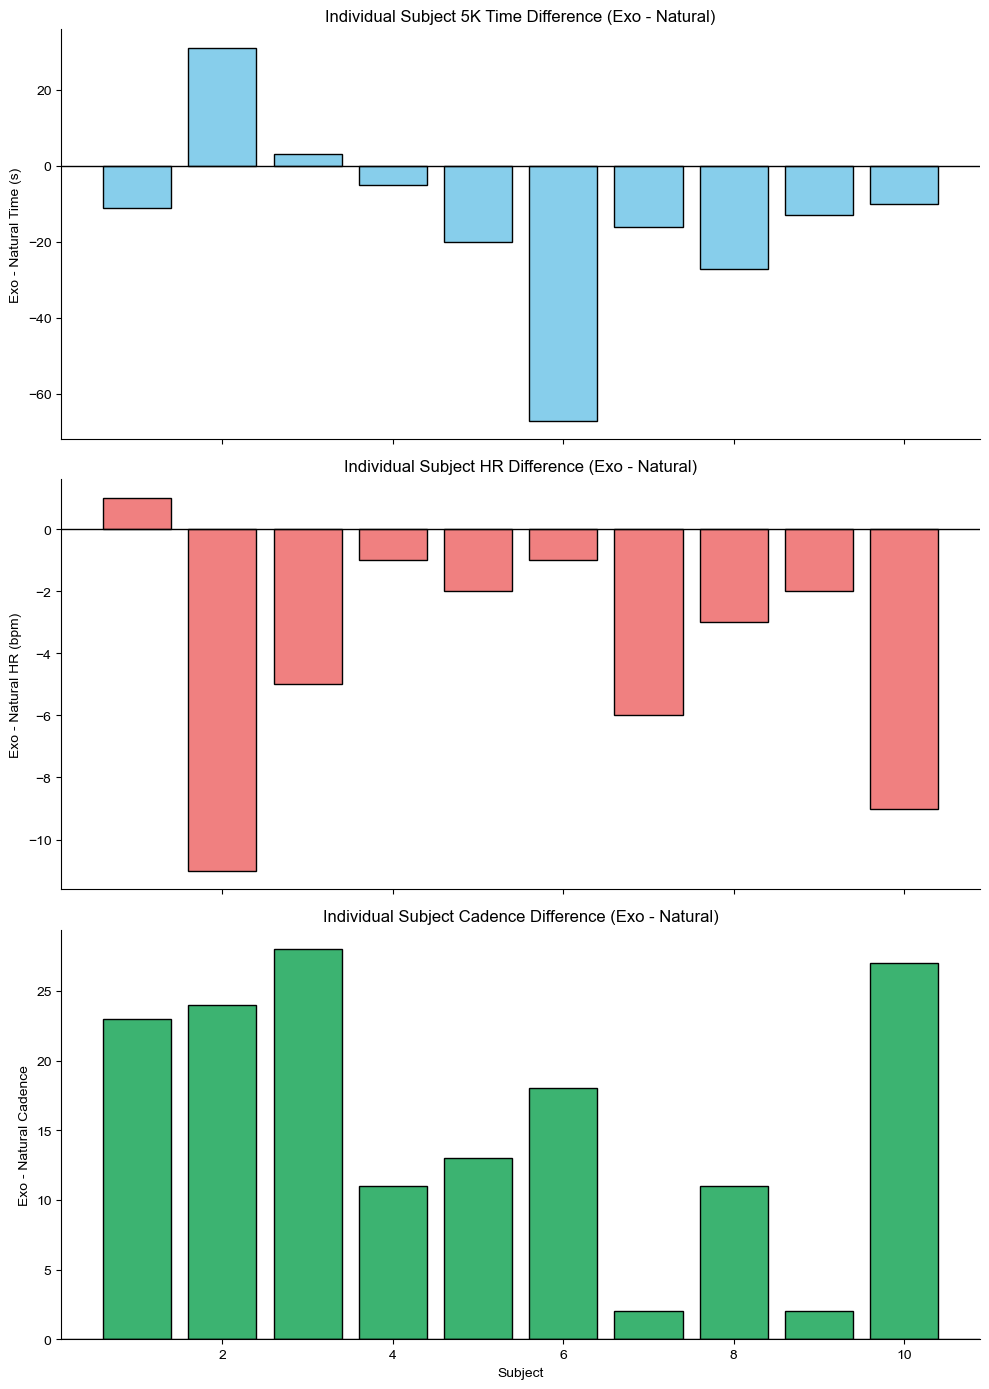

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(10, 14), sharex=True)

subjects = np.arange(1, len(pd_5k) + 1)

# Top panel: Difference between Natural and Exo (time)
diff_time = pd_5k['Exo'] - pd_5k['Natural']
axes[0].bar(subjects, diff_time, color='skyblue', edgecolor='black')
axes[0].set_ylabel('Exo - Natural Time (s)')
axes[0].set_title('Individual Subject 5K Time Difference (Exo - Natural)')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Middle panel: Difference in HR
diff_hr = pd_5k['HeartExo'] - pd_5k['HeartNatural']
axes[1].bar(subjects, diff_hr, color='lightcoral', edgecolor='black')
axes[1].set_ylabel('Exo - Natural HR (bpm)')
axes[1].set_title('Individual Subject HR Difference (Exo - Natural)')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Bottom panel: Difference in Cadence
diff_cadence = pd_5k['CadenceExo'] - pd_5k['CadenceNatural']
axes[2].bar(subjects, diff_cadence, color='mediumseagreen', edgecolor='black')
axes[2].set_ylabel('Exo - Natural Cadence')
axes[2].set_title('Individual Subject Cadence Difference (Exo - Natural)')
axes[2].axhline(0, color='black', linewidth=1)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].set_xlabel('Subject')

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
from IPython.display import display

# Create a publication-ready table showing individual and group-level differences (Exo - Natural)

# Calculate differences for each metric
diff_table = pd.DataFrame({
    'Subject': np.arange(1, len(pd_5k) + 1, dtype=int),
    'Time (Exo - Natural)': (pd_5k['Exo'] - pd_5k['Natural']).astype(float),
    'Heart Rate (Exo - Natural)': (pd_5k['HeartExo'] - pd_5k['HeartNatural']).astype(float),
    'Cadence (Exo - Natural)': (pd_5k['CadenceExo'] - pd_5k['CadenceNatural']).astype(float)
})
diff_table.index = [f"Subject {i+1}" for i in range(len(diff_table))]
diff_table = diff_table.drop(columns=['Subject'])

# Add group mean and std at the bottom
group_mean = diff_table.mean().rename('Mean')
group_std = diff_table.std().rename('Std Dev')
diff_table_pub = pd.concat([diff_table, group_mean.to_frame().T, group_std.to_frame().T])

# Format for publication (rounded values)
diff_table_pub = diff_table_pub.round(2)

# Display as a styled table
# styled_diff_table = diff_table_pub.style.set_caption("Individual and Group Differences (Exo - Natural)").format(precision=2)
# styled_diff_table

# Transpose the table for publication (metrics as rows, subjects as columns)
styled_diff_table_T = diff_table_pub.T.style.set_caption("Individual and Group Differences (Exo - Natural) [Transposed]").format(precision=2)
display(styled_diff_table_T)

# Save the styled table as an Excel file (already present)
styled_diff_table_T.to_excel(os.path.join(os.getcwd(), '../PredFigures/diff_table_transposed.xlsx'))

# # Additionally, save as a high-resolution image for publication (requires dataframe_image)
# import dataframe_image as dfi
# dfi.export(diff_table_pub.T, os.path.join(os.getcwd(), '../PredFigures/diff_table_transposed.png'), dpi=300)

AttributeError: The '.style' accessor requires jinja2

Saved figure to: /Users/jonstingel/Desktop/metabolics/analysis/../PredFigures/natural_to_exotendon_boxplot.png


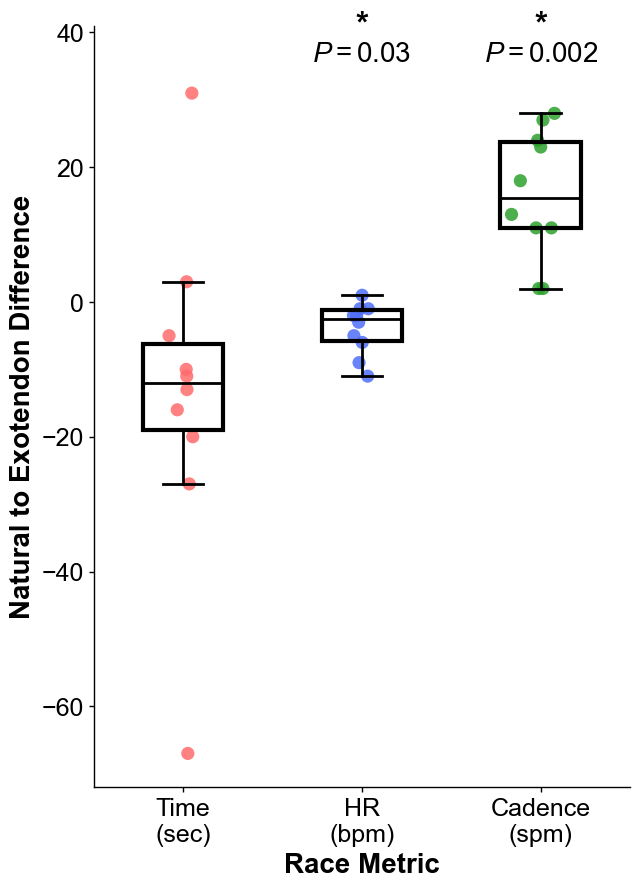

In [18]:
# Create the 3-panel boxplot (Time, HR, Cadence) with individual points
import os
import numpy as np
import matplotlib.pyplot as plt

# Expecting `pd_5k` to already be present in the notebook (read earlier from clipboard)
# Compute change values: Exo - Natural (Natural -> Exotendon change)
time_change = (pd_5k['Exo'] - pd_5k['Natural']).astype(float)
hr_change = (pd_5k['HeartExo'] - pd_5k['HeartNatural']).astype(float)
cad_change = (pd_5k['CadenceExo'] - pd_5k['CadenceNatural']).astype(float)

# Prepare data and plotting parameters
data = [time_change.dropna().values, hr_change.dropna().values, cad_change.dropna().values]
labels = ['Time\n(sec)', 'HR\n(bpm)', 'Cadence\n(spm)']
colors = ['#ff6b6b', '#4f6ef7', '#2ca02c']  # red, blue, green

# Space the x positions out so the figure feels wider
x = np.arange(1, len(data) + 1) * 2.0

# Create figure (wider portrait-like to match requested spacing)
fig, ax = plt.subplots(figsize=(6.5, 9))

# Boxplot with black outlines and no facecolor (we'll show colored points underneath)
box = ax.boxplot(data,
                 positions=x,
                 widths=0.9,
                 patch_artist=True,
                 showfliers=False,
                 boxprops=dict(facecolor='none', linewidth=3, color='black'),
                 medianprops=dict(color='black', linewidth=2),
                 whiskerprops=dict(color='black', linewidth=2),
                 capprops=dict(color='black', linewidth=2))

# Overlay individual subject points with a small horizontal jitter (drawn under the boxes)
rng = np.random.default_rng(1)
for i, ys in enumerate(data):
    if len(ys) == 0:
        continue
    xs = rng.normal(loc=x[i], scale=0.12, size=len(ys))
    ax.scatter(xs, ys, s=90, color=colors[i], alpha=0.85, edgecolors='None', linewidths=0.7, zorder=2)

# Ensure boxplot artists are on top by increasing their z-order
for key in ('boxes', 'medians', 'whiskers', 'caps', 'fliers'):
    for artist in box.get(key, []):
        try:
            artist.set_zorder(5)
        except Exception:
            pass

# Labels, ticks, style
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=20)
ax.set_xlabel('Race Metric', fontsize=20, fontweight='normal')
ax.set_ylabel('Natural to Exotendon Difference', fontsize=20, fontweight='normal')

# Remove top/right spines and keep left/bottom at normal width
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Tighten y-limits a bit around data for good visual padding
ymin = min([np.min(d) for d in data if len(d) > 0])
ymax = max([np.max(d) for d in data if len(d) > 0])
yrange = ymax - ymin if ymax > ymin else 1.0
ax.set_ylim(ymin - 0.25 * yrange, ymax + 0.25 * yrange)

# Add significance stars above HR and Cadence (both significant) and show p-values
# Use mathtext so only the 'P' is italicized
sig_info = {1: r"$\mathit{P}=0.03$", 2: r"$\mathit{P}=0.002$"}  # index -> math-text
star_y = ymax + 0.08 * yrange
p_y_offset = 0.001 * yrange
for idx, ptext in sig_info.items():
    ax.text(x[idx], star_y, '*', ha='center', va='bottom', fontsize=24, color='k', zorder=10, fontweight='bold')
    ax.text(x[idx], star_y - p_y_offset, ptext, ha='center', va='top', fontsize=20, color='k', zorder=10)

# Expand x-limits a bit to avoid cramped outer boxes
ax.set_xlim(x[0] - 1.0, x[-1] + 1.0)
ax.set_ylim(ymin - 5, ymax +10)


# Improve tick sizes and use normal weight for ticks/labels
ax.tick_params(axis='y', labelsize=18, width=1)
ax.tick_params(axis='x', labelsize=18, width=1)
ax.xaxis.label.set_fontweight('bold')
ax.yaxis.label.set_fontweight('bold')

plt.tight_layout()

# Save figure into ../PredFigures (create dir if needed)
outdir = os.path.join(os.getcwd(), '..', 'PredFigures')
os.makedirs(outdir, exist_ok=True)
outpath = os.path.join(outdir, 'natural_to_exotendon_boxplot.png')
fig.savefig(outpath, dpi=300, bbox_inches='tight')
print(f'Saved figure to: {outpath}')
plt.show()


In [19]:
# determine if there are outliers in the time data
time_data = time_change.dropna().values
q1 = np.percentile(time_data, 25)
q3 = np.percentile(time_data, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = time_data[(time_data < lower_bound) | (time_data > upper_bound)]

# compute median and IQR
median = np.median(time_data)
iqr_value = iqr


print(f"Outliers in Time Change: {outliers}")
print('\n')
print('Lower bound for outliers:', lower_bound)
print('Upper bound for outliers:', upper_bound)


print('\n')
print("Summary statistics for Time Change:")
print(f"Mean: {np.mean(time_data)}")
print(f"Median: {np.median(time_data)}")
print(f"Standard Deviation: {np.std(time_data)}")
print(f"Min: {np.min(time_data)}")
print(f"Max: {np.max(time_data)}")

print(f"Median Time Change: {median}")
print(f"IQR Time Change: {iqr_value}")

Outliers in Time Change: [ 31. -67.]


Lower bound for outliers: -38.125
Upper bound for outliers: 12.875


Summary statistics for Time Change:
Mean: -13.5
Median: -12.0
Standard Deviation: 23.316303309058235
Min: -67.0
Max: 31.0
Median Time Change: -12.0
IQR Time Change: 12.75


In [16]:
# now do the same outlier analysis and reporting, but use 3 std deviations from the mean instead of IQR
mean_time = np.mean(time_data)
std_time = np.std(time_data)
lower_bound_std = mean_time - 3 * std_time
upper_bound_std = mean_time + 3 * std_time
outliers_std = time_data[(time_data < lower_bound_std) | (time_data > upper_bound_std)]
print(f"Outliers in Time Change (3 std dev): {outliers_std}")
print('\n')
print('Lower bound for outliers (3 std dev):', lower_bound_std)
print('Upper bound for outliers (3 std dev):', upper_bound_std) 


Outliers in Time Change (3 std dev): []


Lower bound for outliers (3 std dev): -83.4489099271747
Upper bound for outliers (3 std dev): 56.4489099271747


In [17]:
# what if we calculate the outliers based on the z score method
z_scores = (time_data - mean_time) / std_time
outliers_z = time_data[np.abs(z_scores) > 3]
print(f"Outliers in Time Change (Z-score method): {outliers_z}")
print(z_scores)

Outliers in Time Change (Z-score method): []
[ 0.10722111  1.90853582  0.70765935  0.36455179 -0.27877489 -2.29453183
 -0.10722111 -0.57899401  0.02144422  0.15010956]


# Trimmed metabolic data - including only the aerobic trials! 

In [3]:
## work on the box plot but trim out the anaerobic trials on a trial basis... 
# leave in data for the subject where they are aerobic. 

df_trimmed = df.copy()
df_trimmed.loc[df_trimmed['Subject'] == 13, ['Bad', 'Optimal']] = np.nan
df_trimmed.loc[df_trimmed['Subject'] == 6, 'Bad'] = np.nan
print(df_trimmed)

    Subject  Long-compliant  Short-stiff  Medium-original  Long-stiff  \
0         1       -2.876106   -12.094395       -14.306785   -7.448378   
1         3        3.808864    -5.678670        -4.362881  -12.811634   
2         4       -1.889169    -7.367758        -4.785894   -4.534005   
3         6        0.189633    -1.327434        -2.844501    1.201011   
4         7       -3.957947    -6.060606        -6.679035   -5.009276   
5         8       -4.116866    -8.565737       -10.823373    4.316069   
6         9       -5.058905    -2.841303        -4.712405    0.138600   
7        10       -0.407609     4.959239       -11.005435   -1.902174   
8        11        5.615697     4.533153         8.795670   10.148850   
9        12      -11.160151    -5.548550        -5.233291   -1.324086   
10       13       -2.195390    -4.555434        -6.256861   -4.116356   

    Best-performing  Bad  Optimal  
0        -14.306785  NaN      NaN  
1        -12.811634  NaN      NaN  
2         -7.36

In [4]:
# here are the same data but 5 diff, and then we need to remove the same entries 
df_perc_trimmed = df_trimmed.copy()
df_perc_trimmed.loc[df_perc_trimmed['Subject'] == 13, ['Short-stiff', 'Long-stiff']] = np.nan
df_perc_trimmed.loc[df_perc_trimmed['Subject'] == 6, 'Short-stiff'] = np.nan
print(df_perc_trimmed)

    Subject  Long-compliant  Short-stiff  Medium-original  Long-stiff  \
0         1       -2.876106   -12.094395       -14.306785   -7.448378   
1         3        3.808864    -5.678670        -4.362881  -12.811634   
2         4       -1.889169    -7.367758        -4.785894   -4.534005   
3         6        0.189633          NaN        -2.844501    1.201011   
4         7       -3.957947    -6.060606        -6.679035   -5.009276   
5         8       -4.116866    -8.565737       -10.823373    4.316069   
6         9       -5.058905    -2.841303        -4.712405    0.138600   
7        10       -0.407609     4.959239       -11.005435   -1.902174   
8        11        5.615697     4.533153         8.795670   10.148850   
9        12      -11.160151    -5.548550        -5.233291   -1.324086   
10       13       -2.195390          NaN        -6.256861         NaN   

    Best-performing  Bad  Optimal  
0        -14.306785  NaN      NaN  
1        -12.811634  NaN      NaN  
2         -7.36

/var/folders/_d/s3xm67814b79vmjwbcsk9hn00000gn/T/ipykernel_67793/3308599745.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(modalities_staggered)


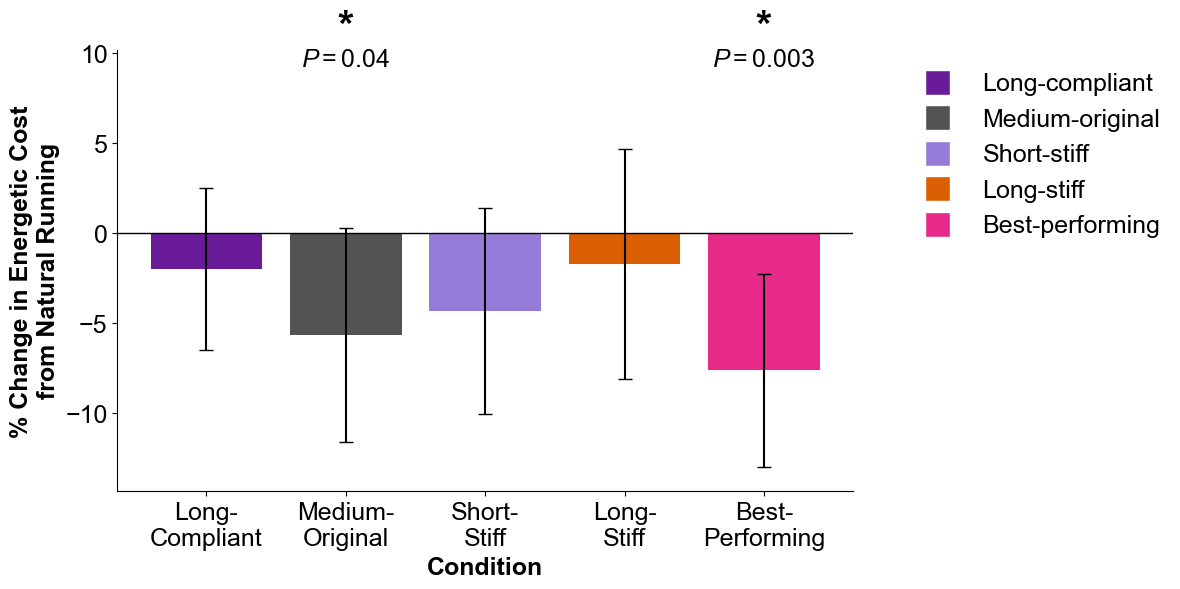

In [11]:
# bar plot aerobic only
# okay one simple bar plot that can go in the paper (with all the data)
# 1) Bar plot with averages and error bars (std)

# create a color map for the conditions
plot_colors = {
    'Short-stiff': "#967cd8",
    'Medium-original': "#535353",
    'Long-stiff': '#d95f02',
    'Long-compliant': '#6A1B9A', # '#1b9e77',
    'Best-performing': '#e7298a'
}



modalities_staggered = ['Long-\nCompliant', 'Medium-\nOriginal', 'Short-\nStiff', 'Long-\nStiff', 'Best-\nPerforming']
modalities = ['Long-compliant', 'Medium-original', 'Short-stiff', 'Long-stiff', 'Best-performing']
means = df_perc_trimmed[modalities].mean()
stds = df_perc_trimmed[modalities].std()
fig, ax = plt.subplots(figsize=(12, 6))

# Bar plot
ax.bar(modalities, means, yerr=stds, capsize=5, color=[plot_colors[m] for m in modalities], edgecolor='None')
# Add legend for modality colors
handles = [plt.Line2D([0], [0], marker='s', color='w', label=modality,
                      markerfacecolor=plot_colors[modality], markersize=18)
           for modality in modalities]
ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=18, frameon=False)


ax.set_ylabel('% Change in Energetic Cost\nfrom Natural Running', fontsize=18, fontweight='bold')
ax.set_xlabel('Condition', fontsize=18, fontweight='bold')
ax.axhline(0, color='black', linewidth=1)

# add significance marker above "Best-individual"
# expand top margin so the star/P-value can sit higher without overlapping the bar
ymin_tmp, ymax_tmp = ax.get_ylim()
yrange_tmp = ymax_tmp - ymin_tmp if ymax_tmp > ymin_tmp else 1.0
ax.set_ylim(ymin_tmp, ymax_tmp + 0.25 * yrange_tmp)
idx = modalities.index('Best-performing')
x = idx  # categorical bars are at integer x positions 0..N-1
ymin_curr, ymax_curr = ax.get_ylim()
yrange = ymax_curr - ymin_curr if ymax_curr > ymin_curr else 1.0
star_y = ymax_curr - 0.05
p_y = star_y - 0.04
# best stats
ax.text(x, star_y, '*', ha='center', va='bottom', fontsize=30, fontweight='bold', zorder=10)
ax.text(x, p_y, r"$\mathit{P}=0.003$", ha='center', va='top', fontsize=18, zorder=10)
# original stats
ax.text(x-3, star_y, '*', ha='center', va='bottom', fontsize=30, fontweight='bold', zorder=10)
ax.text(x-3, p_y, r"$\mathit{P}=0.04$", ha='center', va='top', fontsize=18, zorder=10)


# Ensure y-limits as before
ymin = min(df_perc_trimmed[modalities].min().min(), means.min() - stds.max())
ymax = max(df_perc_trimmed[modalities].max().max(), means.max() + stds.max())
ax.set_ylim(ymin, ymax)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.set_xticklabels(modalities_staggered)


# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
fig.savefig(os.path.join(os.getcwd(), '../PredFigures/scores_by_modality_singlePanel_aerobic.png'), dpi=500, bbox_inches='tight')


/var/folders/_d/s3xm67814b79vmjwbcsk9hn00000gn/T/ipykernel_67793/3759379047.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(modalities_staggered_plot)


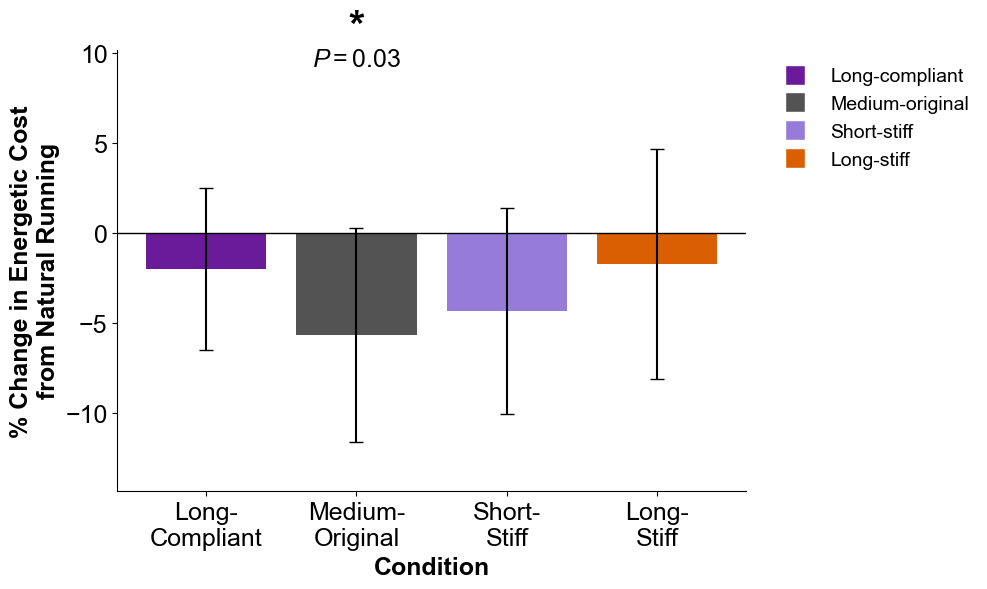

In [14]:
# bar plot aerobic only (first 4 conditions only)

modalities_plot = modalities[:-1]
modalities_staggered_plot = modalities_staggered[:-1]

means = df_perc_trimmed[modalities_plot].mean()
stds = df_perc_trimmed[modalities_plot].std()

fig, ax = plt.subplots(figsize=(10, 6))

# Bar plot (exclude last bar: Best-performing)
ax.bar(
    modalities_plot,
    means,
    yerr=stds,
    capsize=5,
    color=[plot_colors[m] for m in modalities_plot],
    edgecolor='None'
)

# Legend for plotted conditions only
handles = [
    plt.Line2D([0], [0], marker='s', color='w', label=m,
               markerfacecolor=plot_colors[m], markersize=14)
    for m in modalities_plot
]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=14, frameon=False)

ax.set_ylabel('% Change in Energetic Cost\nfrom Natural Running', fontsize=18, fontweight='bold')
ax.set_xlabel('Condition', fontsize=18, fontweight='bold')
ax.axhline(0, color='black', linewidth=1)

# y-limits
ymin = min(df_perc_trimmed[modalities_plot].min().min(), means.min() - stds.max())
ymax = max(df_perc_trimmed[modalities_plot].max().max(), means.max() + stds.max())
ax.set_ylim(ymin, ymax)

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.set_xticklabels(modalities_staggered_plot)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# original stats
ax.text(x-3, star_y, '*', ha='center', va='bottom', fontsize=30, fontweight='bold', zorder=10)
ax.text(x-3, p_y, r"$\mathit{P}=0.03$", ha='center', va='top', fontsize=18, zorder=10)

plt.tight_layout()
plt.show()

fig.savefig(
    os.path.join(os.getcwd(), '../PredFigures/scores_by_modality_singlePanel_aerobic_first4.png'),
    dpi=500,
    bbox_inches='tight'
)


/var/folders/_d/s3xm67814b79vmjwbcsk9hn00000gn/T/ipykernel_59511/410696092.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(modalities_staggered)
/var/folders/_d/s3xm67814b79vmjwbcsk9hn00000gn/T/ipykernel_59511/410696092.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(modalities_staggered[0:-1])


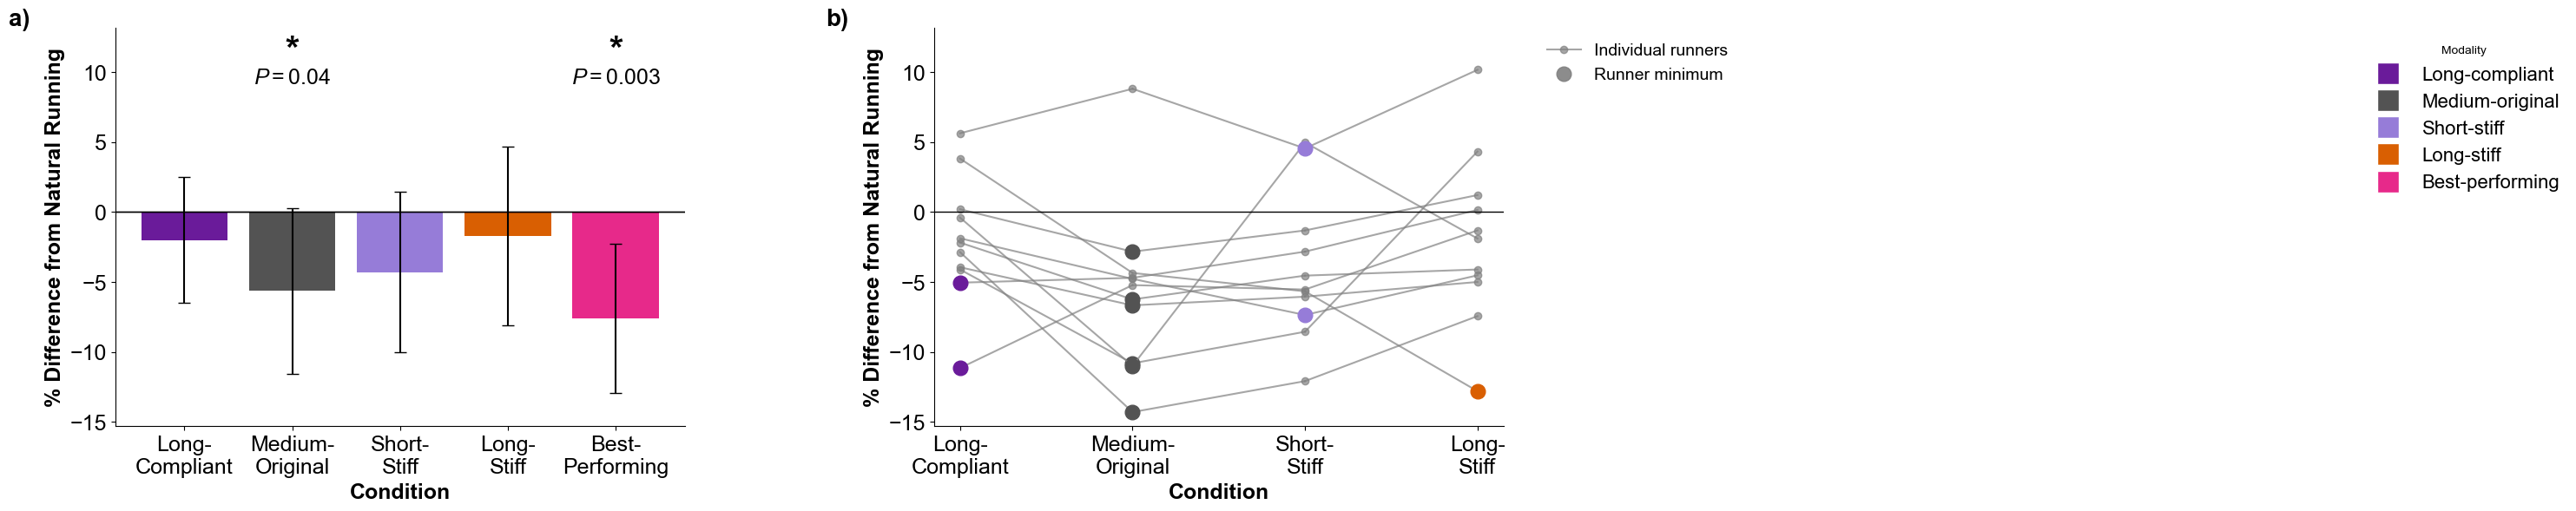

In [8]:
# now we are going to make this into a 2 panel, where the second panel is the individual subject lines but only for the aerobic trials.
from matplotlib.lines import Line2D
# 1) Bar plot with averages and error bars (std)

# create a color map for the conditions
plot_colors = {
    'Short-stiff': "#967cd8",
    'Medium-original': "#535353",
    'Long-stiff': '#d95f02',
    'Long-compliant': '#6A1B9A', # '#1b9e77',
    'Best-performing': '#e7298a'
}



modalities_staggered = ['Long-\nCompliant', 'Medium-\nOriginal', 'Short-\nStiff', 'Long-\nStiff', 'Best-\nPerforming']
modalities = ['Long-compliant', 'Medium-original', 'Short-stiff', 'Long-stiff', 'Best-performing']
means = df_perc_trimmed[modalities].mean()
stds = df_perc_trimmed[modalities].std()
fig, axs = plt.subplots(1, 3, figsize=(30, 6))
fig.subplots_adjust(wspace=0.01)

# Bar plot
axs[0].bar(modalities, means, yerr=stds, capsize=5, color=[plot_colors[m] for m in modalities], edgecolor='None')
# Add legend for modality colors
handles = [plt.Line2D([0], [0], marker='s', color='w', label=modality,
                      markerfacecolor=plot_colors[modality], markersize=18)
           for modality in modalities]
axs[2].axis('off')  # hide the third subplot (used just for legend)
axs[2].legend(handles=handles, title='Modality', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16, frameon=False)


axs[0].set_ylabel('% Difference from Natural Running', fontsize=18, fontweight='bold')
axs[0].set_xlabel('Condition', fontsize=18, fontweight='bold')
axs[0].axhline(0, color='black', linewidth=1)

# add significance marker above "Best-individual"
# expand top margin so the star/P-value can sit higher without overlapping the bar
ymin_tmp, ymax_tmp = axs[0].get_ylim()
yrange_tmp = ymax_tmp - ymin_tmp if ymax_tmp > ymin_tmp else 1.0
axs[0].set_ylim(ymin_tmp, ymax_tmp + 0.25 * yrange_tmp)
idx = modalities.index('Best-performing')
x = idx  # categorical bars are at integer x positions 0..N-1
ymin_curr, ymax_curr = axs[0].get_ylim()
yrange = ymax_curr - ymin_curr if ymax_curr > ymin_curr else 1.0
star_y = ymax_curr - 0.05
p_y = star_y - 0.04
# best stats
axs[0].text(x, star_y, '*', ha='center', va='bottom', fontsize=30, fontweight='bold', zorder=10)
axs[0].text(x, p_y, r"$\mathit{P}=0.003$", ha='center', va='top', fontsize=18, zorder=10)
# original stats
axs[0].text(x-3, star_y, '*', ha='center', va='bottom', fontsize=30, fontweight='bold', zorder=10)
axs[0].text(x-3, p_y, r"$\mathit{P}=0.04$", ha='center', va='top', fontsize=18, zorder=10)


# Ensure y-limits as before
ymin = min(df_perc_trimmed[modalities].min().min(), means.min() - stds.max())
ymax = max(df_perc_trimmed[modalities].max().max(), means.max() + stds.max())
axs[0].set_ylim(ymin, ymax)
axs[0].tick_params(axis='x', labelsize=18)
axs[0].tick_params(axis='y', labelsize=18)
axs[0].set_xticklabels(modalities_staggered)


# Remove top and right borders
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

# 2) Scatter plot with lines for each subject, connecting all but "Best"
# Plot each subject's curve with color based on their minimum point
for idx, row in df.iterrows():
    # Find the minimum value among all modalities (excluding Best-individual)
    min_idx = row[modalities[:-1]].idxmin()
    
    # Get the color based on the minimum condition
    line_color = plot_colors.get(min_idx, 'grey')
    
    # Find the position of the minimum in the modalities list
    min_pos = modalities.index(min_idx)
    
    # Plot lines connecting all modalities except "Best" in the subject's color
    for i in range(len(modalities[:-1]) - 1):
        axs[1].plot(modalities[i:i+2], row[modalities[i:i+2]], 
                   color='grey', alpha=0.7, linewidth=1.5)
    
    # Plot all markers with standard size
    for i, mod in enumerate(modalities[:-1]):
        if i == min_pos:
            # Make the minimum point marker larger
            axs[1].plot(mod, row[mod], marker='o', markersize=12, 
                       color=line_color, alpha=1)
        else:
            axs[1].plot(mod, row[mod], marker='o', markersize=6, 
                       color='grey', alpha=0.7)

axs[0].axhline(0, color='black', linewidth=1)
axs[1].axhline(0, color='black', linewidth=1)
# axs[1].set_title('% Difference from Natural per Subject')
axs[1].set_ylabel('% Difference from Natural Running', fontsize=18, fontweight='bold')
axs[1].set_xlabel('Condition', fontsize=18, fontweight='bold')
axs[1].set_xticklabels(modalities_staggered[0:-1])

legend_elements = [
    Line2D([0], [0], color='grey', marker='o', markersize=6, linewidth=1.5, alpha=0.7, label='Individual runners'),
    Line2D([0], [0], color='none', marker='o', markerfacecolor='grey', markeredgecolor='grey', markersize=12, linewidth=0, alpha=0.9, label='Runner minimum')
]
axs[1].legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, frameon=False)
# # Get current y-limits to position legend in upper white space
# ymin_curr, ymax_curr = axs[1].get_ylim()
# # Position legend at approximately 70% of the y-range (middle of upper white space)
# legend_y = ymin_curr + 0.70 * (ymax_curr - ymin_curr)
# axs[1].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.3, 0.98), fontsize=14, frameon=False)

# Add panel letters to subplots
axs[0].text(-0.15, 1.05, 'a)', transform=axs[0].transAxes, 
            fontsize=20, fontweight='bold', va='top', ha='right')
axs[1].text(-0.15, 1.05, 'b)', transform=axs[1].transAxes, 
            fontsize=20, fontweight='bold', va='top', ha='right')

# Ensure both axes have the same y-axis limits
ymin = min(df[modalities].min().min(), means.min() - stds.max())
ymax = max(df[modalities].max().max(), means.max() + stds.max())
axs[0].set_ylim(ymin-1, ymax+3)
axs[1].set_ylim(ymin-1, ymax+3)

# Remove top and right borders for both subplots
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axs[1].tick_params(axis='x', labelsize=18)
axs[1].tick_params(axis='y', labelsize=18)

plt.tight_layout()
plt.show()
fig.savefig(os.path.join(os.getcwd(), '../PredFigures/scores_by_modality_dualPanel.png'), dpi=300, bbox_inches='tight')


/var/folders/_d/s3xm67814b79vmjwbcsk9hn00000gn/T/ipykernel_9482/3842262972.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(modalities_staggered)
/var/folders/_d/s3xm67814b79vmjwbcsk9hn00000gn/T/ipykernel_9482/3842262972.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(modalities_staggered[0:-1])


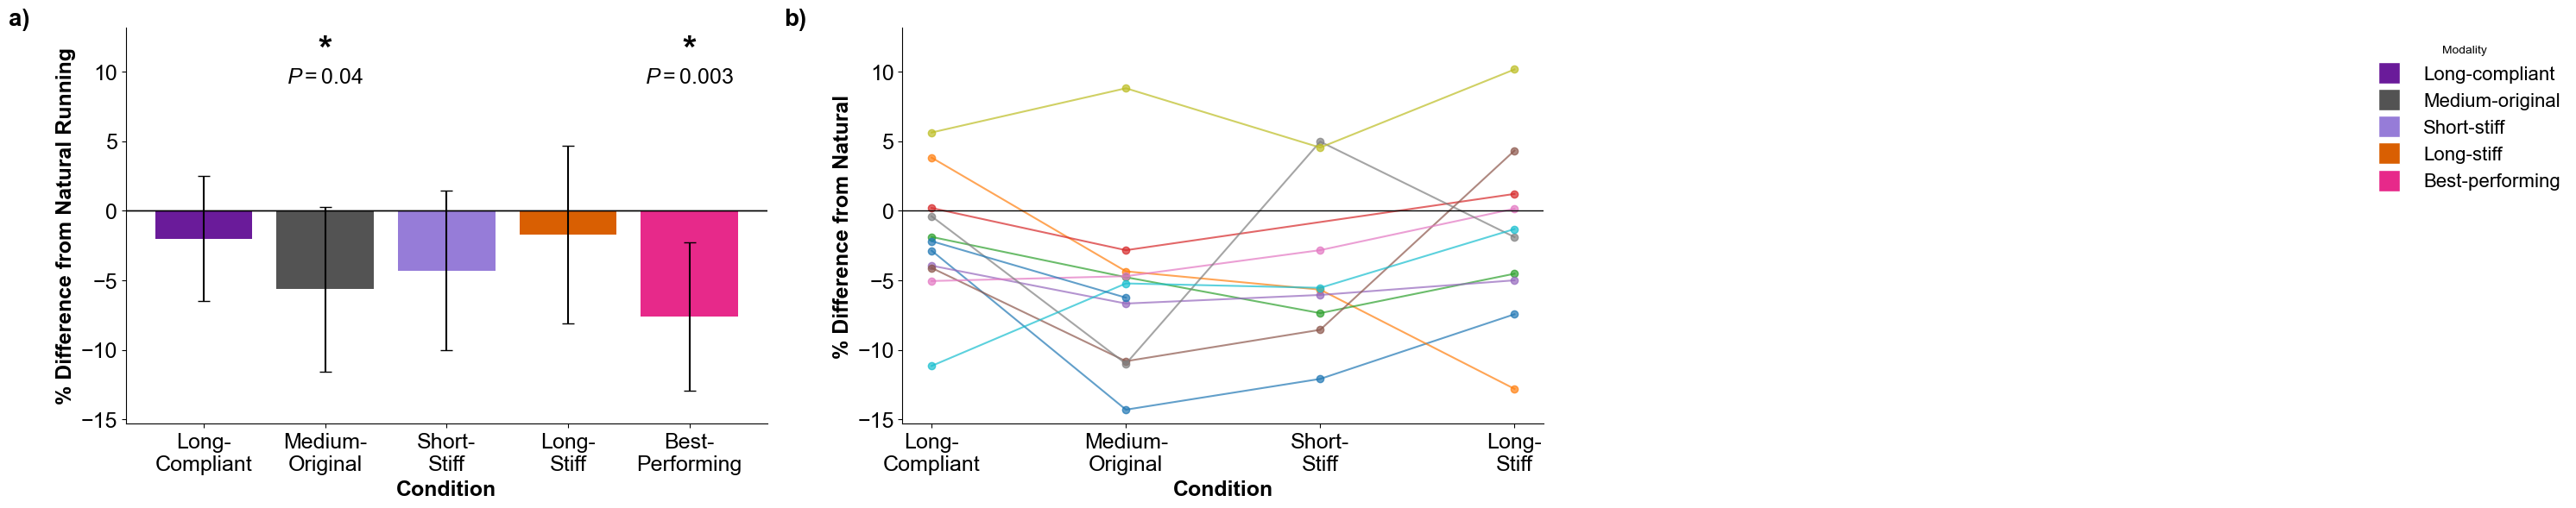

In [16]:
# now we are going to make this into a 2 panel, where the second panel is the individual subject lines but only for the aerobic trials.
from matplotlib.lines import Line2D
# 1) Bar plot with averages and error bars (std)

# create a color map for the conditions
plot_colors = {
    'Short-stiff': "#967cd8",
    'Medium-original': "#535353",
    'Long-stiff': '#d95f02',
    'Long-compliant': '#6A1B9A', # '#1b9e77',
    'Best-performing': '#e7298a'
}



modalities_staggered = ['Long-\nCompliant', 'Medium-\nOriginal', 'Short-\nStiff', 'Long-\nStiff', 'Best-\nPerforming']
modalities = ['Long-compliant', 'Medium-original', 'Short-stiff', 'Long-stiff', 'Best-performing']
means = df_perc_trimmed[modalities].mean()
stds = df_perc_trimmed[modalities].std()
fig, axs = plt.subplots(1, 3, figsize=(30, 6))
fig.subplots_adjust(wspace=0.01)

# Bar plot
axs[0].bar(modalities, means, yerr=stds, capsize=5, color=[plot_colors[m] for m in modalities], edgecolor='None')
# Add legend for modality colors
handles = [plt.Line2D([0], [0], marker='s', color='w', label=modality,
                      markerfacecolor=plot_colors[modality], markersize=18)
           for modality in modalities]
axs[2].axis('off')  # hide the third subplot (used just for legend)
axs[2].legend(handles=handles, title='Modality', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16, frameon=False)


axs[0].set_ylabel('% Difference from Natural Running', fontsize=18, fontweight='bold')
axs[0].set_xlabel('Condition', fontsize=18, fontweight='bold')
axs[0].axhline(0, color='black', linewidth=1)

# add significance marker above "Best-individual"
# expand top margin so the star/P-value can sit higher without overlapping the bar
ymin_tmp, ymax_tmp = axs[0].get_ylim()
yrange_tmp = ymax_tmp - ymin_tmp if ymax_tmp > ymin_tmp else 1.0
axs[0].set_ylim(ymin_tmp, ymax_tmp + 0.25 * yrange_tmp)
idx = modalities.index('Best-performing')
x = idx  # categorical bars are at integer x positions 0..N-1
ymin_curr, ymax_curr = axs[0].get_ylim()
yrange = ymax_curr - ymin_curr if ymax_curr > ymin_curr else 1.0
star_y = ymax_curr - 0.05
p_y = star_y - 0.04
# best stats
axs[0].text(x, star_y, '*', ha='center', va='bottom', fontsize=30, fontweight='bold', zorder=10)
axs[0].text(x, p_y, r"$\mathit{P}=0.003$", ha='center', va='top', fontsize=18, zorder=10)
# original stats
axs[0].text(x-3, star_y, '*', ha='center', va='bottom', fontsize=30, fontweight='bold', zorder=10)
axs[0].text(x-3, p_y, r"$\mathit{P}=0.04$", ha='center', va='top', fontsize=18, zorder=10)


# Ensure y-limits as before
ymin = min(df_perc_trimmed[modalities].min().min(), means.min() - stds.max())
ymax = max(df_perc_trimmed[modalities].max().max(), means.max() + stds.max())
axs[0].set_ylim(ymin, ymax)
axs[0].tick_params(axis='x', labelsize=18)
axs[0].tick_params(axis='y', labelsize=18)
axs[0].set_xticklabels(modalities_staggered)


# Remove top and right borders
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

# 2) Scatter plot with lines for each subject, connecting all but "Best"
for _, row in df_perc_trimmed.iterrows():
    # keep only non-NaN points among aerobic trial modalities
    y = row[modalities[:-1]].dropna()

    # plot remaining points; missing conditions are skipped but line stays connected
    axs[1].plot(
        y.index, y.values,
        marker='o',
        alpha=0.7,
        linewidth=1.5
    )





axs[0].axhline(0, color='black', linewidth=1)
axs[1].axhline(0, color='black', linewidth=1)
# axs[1].set_title('% Difference from Natural per Subject')
axs[1].set_ylabel('% Difference from Natural', fontsize=18, fontweight='bold')
axs[1].set_xlabel('Condition', fontsize=18, fontweight='bold')
axs[1].set_xticklabels(modalities_staggered[0:-1])

# legend_elements = [
#     Line2D([0], [0], color='grey', marker='o', markersize=6, linewidth=1.5, alpha=0.7, label='Individual runners'),
#     Line2D([0], [0], color='none', marker='o', markerfacecolor='grey', markeredgecolor='grey', markersize=12, linewidth=0, alpha=0.9, label='Runner minimum')
# ]
# axs[1].legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, frameon=False)
# # Get current y-limits to position legend in upper white space
# ymin_curr, ymax_curr = axs[1].get_ylim()
# # Position legend at approximately 70% of the y-range (middle of upper white space)
# legend_y = ymin_curr + 0.70 * (ymax_curr - ymin_curr)
# axs[1].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.3, 0.98), fontsize=14, frameon=False)

# Add panel letters to subplots
axs[0].text(-0.15, 1.05, 'a)', transform=axs[0].transAxes, 
            fontsize=20, fontweight='bold', va='top', ha='right')
axs[1].text(-0.15, 1.05, 'b)', transform=axs[1].transAxes, 
            fontsize=20, fontweight='bold', va='top', ha='right')

# Ensure both axes have the same y-axis limits
ymin = min(df_perc_trimmed[modalities].min().min(), means.min() - stds.max())
ymax = max(df_perc_trimmed[modalities].max().max(), means.max() + stds.max())
axs[0].set_ylim(ymin-1, ymax+3)
axs[1].set_ylim(ymin-1, ymax+3)
axs[1].tick_params(axis='x', labelsize=18)
axs[1].tick_params(axis='y', labelsize=18)

# Remove top and right borders for both subplots
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
fig.savefig(os.path.join(os.getcwd(), '../PredFigures/scores_by_modality_dualPanel.png'), dpi=300, bbox_inches='tight')


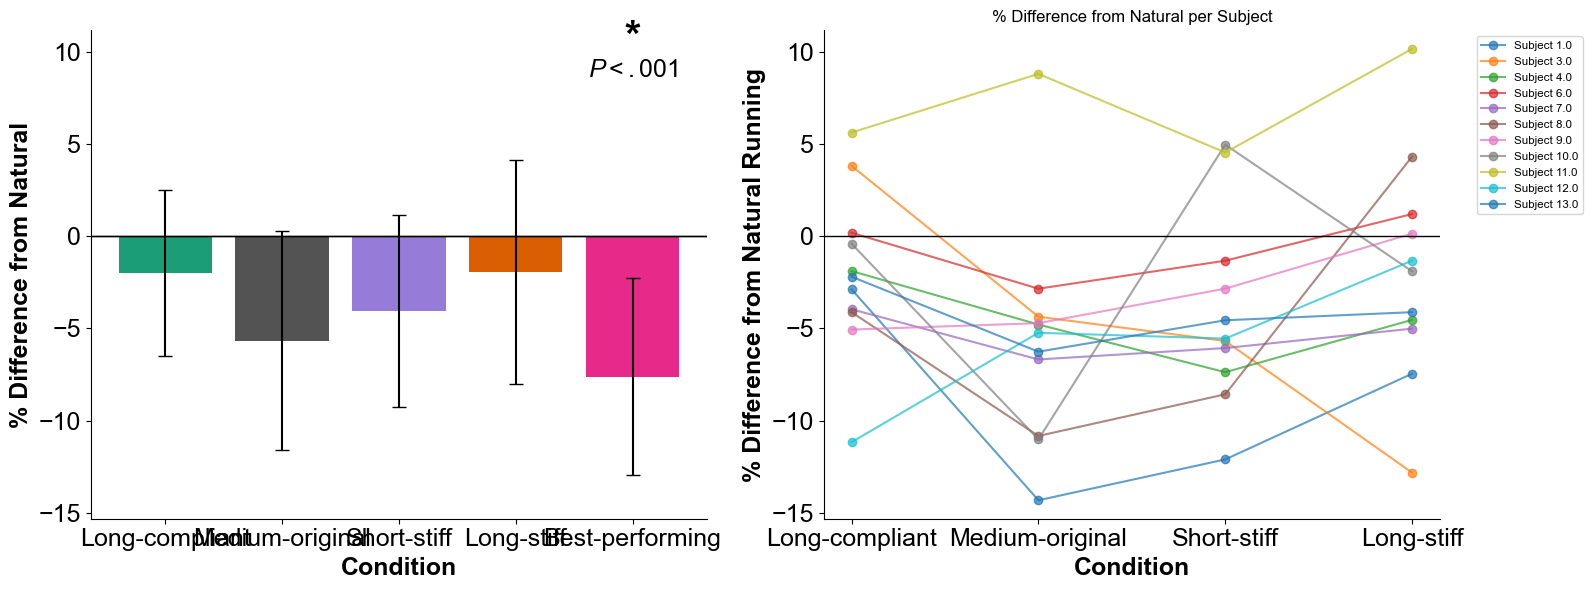

In [15]:
# updating this figure mainly to get the variation part with different formatting. 

# 1) Bar plot with averages and error bars (std)
modalities = ['Long-compliant', 'Short-stiff', 'Medium-original', 'Long-stiff', 'Best-performing']
means = df[modalities].mean()
stds = df[modalities].std()



# create a color map for the conditions
plot_colors = {
    'Short-stiff': "#967cd8",
    'Medium-original': "#535353",
    'Long-stiff': '#d95f02',
    'Long-compliant': '#1b9e77',
    'Best-performing': '#e7298a'
}

modalities = ['Long-compliant', 'Medium-original', 'Short-stiff', 'Long-stiff', 'Best-performing']
means = df[modalities].mean()
stds = df[modalities].std()
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
axs[0].bar(modalities, means, yerr=stds, capsize=5, color=[plot_colors[m] for m in modalities], edgecolor='None')


axs[0].set_ylabel('% Difference from Natural', fontsize=18, fontweight='bold')
axs[0].set_xlabel('Condition', fontsize=18, fontweight='bold')
axs[0].axhline(0, color='black', linewidth=1)

# add significance marker above "Best-performing"
# expand top margin so the star/P-value can sit higher without overlapping the bar
ymin_tmp, ymax_tmp = axs[0].get_ylim()
yrange_tmp = ymax_tmp - ymin_tmp if ymax_tmp > ymin_tmp else 1.0
axs[0].set_ylim(ymin_tmp, ymax_tmp + 0.25 * yrange_tmp)
idx = modalities.index('Best-performing')
x = idx  # categorical bars are at integer x positions 0..N-1
ymin_curr, ymax_curr = axs[0].get_ylim()
yrange = ymax_curr - ymin_curr if ymax_curr > ymin_curr else 1.0
star_y = ymax_curr - 0.05
p_y = star_y - 0.04
axs[0].text(x, star_y, '*', ha='center', va='bottom', fontsize=30, fontweight='bold', zorder=10)
axs[0].text(x, p_y, r"$\mathit{P}<.001$", ha='center', va='top', fontsize=18, zorder=10)


# 2) Scatter plot with lines for each subject, connecting all but "Best"
for idx, row in df.iterrows():
    # Plot lines connecting Placebo, Bad, Original, Optimal
    axs[1].plot(modalities[:-1], row[modalities[:-1]], marker='o', alpha=0.7, label=f'Subject {row["Subject"]}')
    # Plot "Best" as a separate point (not connected)
    # axs[1].plot(modalities[-1], row[modalities[-1]], marker='o', color=axs[1].lines[-1].get_color(), alpha=0.7)
axs[0].axhline(0, color='black', linewidth=1)
axs[1].axhline(0, color='black', linewidth=1)
axs[1].set_title('% Difference from Natural per Subject')
axs[1].set_ylabel('% Difference from Natural Running', fontsize=18, fontweight='bold')
axs[1].set_xlabel('Condition', fontsize=18, fontweight='bold')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')


# Ensure both axes have the same y-axis limits
ymin = min(df[modalities].min().min(), means.min() - stds.max())
ymax = max(df[modalities].max().max(), means.max() + stds.max())
axs[0].set_ylim(ymin-1, ymax+1)
axs[1].set_ylim(ymin-1, ymax+1)

# Remove top and right borders for both subplots
for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axs[0].tick_params(axis='x', labelsize=18)
axs[0].tick_params(axis='y', labelsize=18)
axs[1].tick_params(axis='x', labelsize=18)
axs[1].tick_params(axis='y', labelsize=18)

plt.tight_layout()
plt.show()
fig.savefig(os.path.join(os.getcwd(), '../PredFigures/scores_by_modality_dualPanel.png'), dpi=300, bbox_inches='tight')
